In [41]:
import matplotlib.pyplot as plt
import torch
import librosa
import numpy as np
from transformers import AutoProcessor, MusicgenForConditionalGeneration
import utils

# 1. Load the model and processor
# (musicgen-small works great for extracting attention weights without using too much VRAM)
processor = AutoProcessor.from_pretrained("facebook/musicgen-small")
model = MusicgenForConditionalGeneration.from_pretrained(
    "facebook/musicgen-small",
    attn_implementation="eager"
    )


# 2. Load and preprocess your song (or an audio snippet)
# MusicGen expects a sampling rate of 32,000 Hz
audio_path = "../music-clips/classical_12.wav"  # Replace with your song file
audio, sr = librosa.load(audio_path, sr=32000, duration=60.0)  # Analyze the first 10 seconds

# Preprocess the audio and an optional text query to guide the cross-attention analysis
inputs = processor(
    audio=audio,
    sampling_rate=sr,
    text=[""],  # Optional text to analyze cross-attention alignments
    padding=True,
    return_tensors="pt"
)

# 4. Encode audio and get text representations
with torch.no_grad():
    # Convert audio to EnCodec tokens (audio codes)
    audio_features = inputs["input_values"]
    decoder_input_ids = model.audio_encoder.encode(audio_features).audio_codes
    
    # dummy conditioning: shape must match what the decoder expects
    batch_size = decoder_input_ids.shape[0]
    dummy_encoder_hidden_states = torch.zeros(
        batch_size,
        1,
        1024,  # musicgen-small hidden size
        device=decoder_input_ids.device
    )
    # We must pass the text encoder's hidden states as cross-attention conditioning
    decoder_outputs = model.decoder(
        input_ids=decoder_input_ids,
        encoder_hidden_states=dummy_encoder_hidden_states,  # Map the correct 1024 shape here        output_attentions=True,
        output_attentions=True,
        return_dict=True
    )

# 6. Extract the Self-Attentions directly from the decoder's output
# This will now successfully contain a tuple of 24 layers (for musicgen-small)
self_attentions = decoder_outputs.attentions

print(f"Success! Number of self-attention layers: {len(self_attentions)}")
print(f"Layer 0 shape: {self_attentions[0].shape}")

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

Success! Number of self-attention layers: 24
Layer 0 shape: torch.Size([1, 16, 3000, 3000])


In [42]:
# MusicGen's EnCodec frame rate is exactly 50 Hz (50 tokens per second)
frame_rate = 50.0  

# 1. Construct the pairwise distance matrix in steps
seq_len = decoder_input_ids.shape[-1]
num_layers = len(self_attentions)
num_heads = self_attentions[0].shape[1]
steps = np.arange(seq_len)
distance_matrix = np.abs(steps[:, None] - steps[None, :])

# 2. Convert steps directly to seconds: 1 step = 0.02 seconds (20ms)
distance_in_seconds = distance_matrix / frame_rate
distance_tensor_sec = torch.tensor(distance_in_seconds, dtype=torch.float32, device=self_attentions[0].device)

# 3. Compute Mean Attention Distance in seconds
mean_distances_seconds = np.zeros((num_layers, num_heads))

for layer_idx in range(num_layers):
    layer_attn = self_attentions[layer_idx][0] 
    
    # Weighted sum of distances in seconds
    weighted_distances = layer_attn * distance_tensor_sec
    token_mean_distances = torch.sum(weighted_distances, dim=-1)
    head_mean_distances = torch.mean(token_mean_distances, dim=-1)
    
    mean_distances_seconds[layer_idx] = head_mean_distances.cpu().numpy()

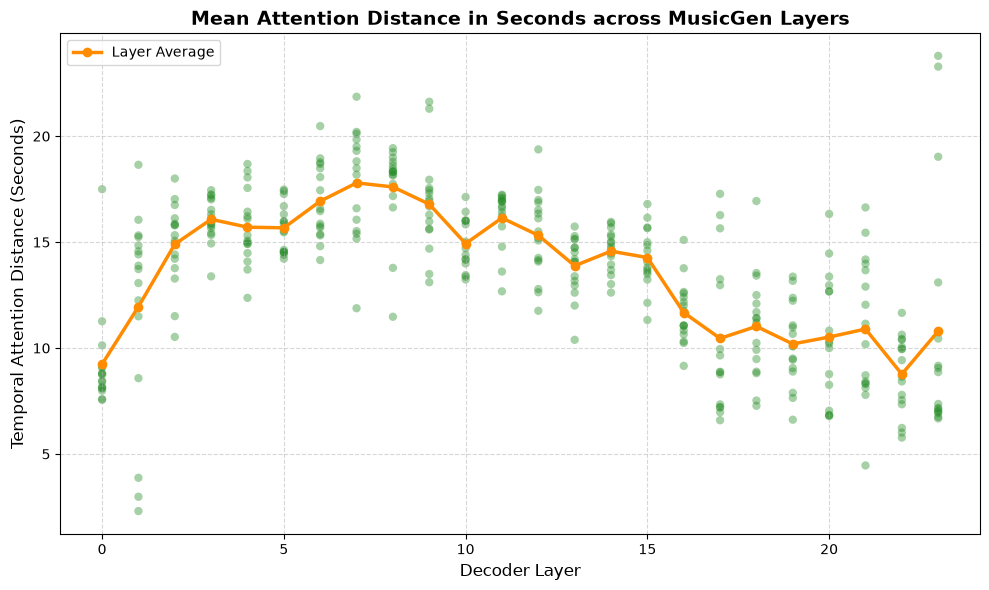

In [43]:
plt.figure(figsize=(10, 6))

for layer in range(num_layers):
    x_coords = [layer] * num_heads
    y_coords = mean_distances_seconds[layer]
    plt.scatter(x_coords, y_coords, color='forestgreen', alpha=0.4, edgecolors='none')

layer_averages_sec = np.mean(mean_distances_seconds, axis=1)
plt.plot(range(num_layers), layer_averages_sec, color='darkorange', linewidth=2.5, marker='o', label='Layer Average')

plt.title("Mean Attention Distance in Seconds across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Decoder Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Seconds)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

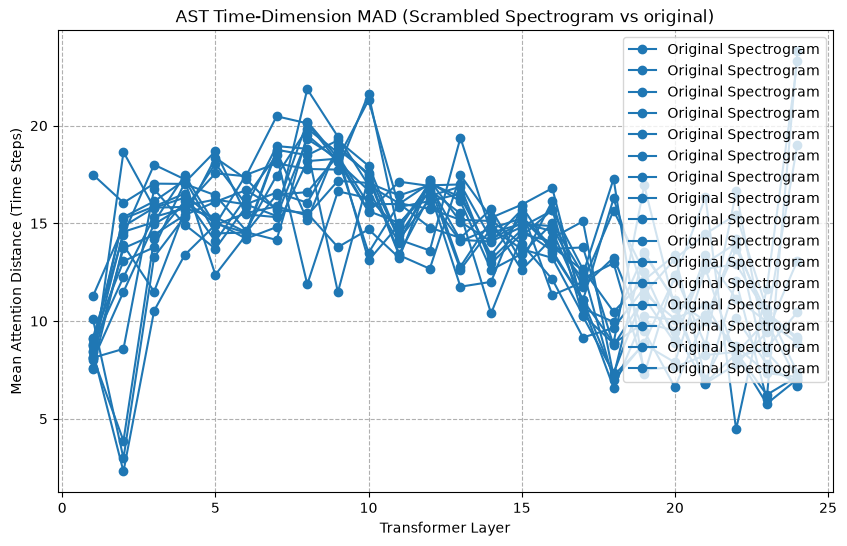

In [44]:
layers = np.arange(1, 25)
plt.figure(figsize=(10, 6))
plt.plot(layers, mean_distances_seconds, marker='o', color='#1f77b4', label='Original Spectrogram')
plt.title('AST Time-Dimension MAD (Scrambled Spectrogram vs original)')
plt.xlabel('Transformer Layer')
plt.ylabel('Mean Attention Distance (Time Steps)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()